### Replications: 9 - 10

- peak range:  $11.05 < \log M_\star/M_\odot < 11.55$

In [2]:
import caesar
import numpy as np
import matplotlib.pyplot as plt
import unyt

from functions import *
unit = 'Mpc/h'

# find file corresponding to redshift z=0.5
print(caesar.progen.z_to_snap(0.5))

# load file corresponding to redshift z=0.5
infile = 'data/m50n512_125.hdf5'
obj = caesar.load(infile)

yt : [INFO     ] 2024-05-29 15:05:00,828 Opening data/m50n512_125.hdf5
yt : [INFO     ] 2024-05-29 15:05:00,875 Found 61977 halos
yt : [INFO     ] 2024-05-29 15:05:00,887 Found 5685 galaxies


(125, 0.49043513253694404)


In [3]:
# distribution of observed stellar mass
original_x = np.arange(9.95,12.35,0.1)
original_y = np.array([2,7,2,4,6,
                10,18,37,93,391,
                2656,13936,26446,23258,25919,
                16346,12119,6851,2678,1361,
                383,134,22,10,4])
N_gal_obs_total = np.sum(original_y)

# mass distribution BOSS and Simba
stellar_mass = np.array([i.masses["stellar"] for i in obj.galaxies])
hist, edges = np.histogram(np.log10(stellar_mass), original_x)

replications = 10

In [4]:
boxsize= obj.simulation.boxsize.to(unit)

# Number of times the box is replicated in each dimension
replications = 10

# Create the offsets for each dimension
offsets = np.arange(replications) * boxsize

# Use np.meshgrid to generate the grid of offsets in 3D
dx, dy, dz = np.meshgrid(offsets, offsets, offsets)

# Flatten the meshgrid arrays and stack them to get a (3, replications^3) array of offsets
offsets_combined = np.vstack([dx.flatten(), dy.flatten(), dz.flatten()])

# galaxies outside the mass range peak
pos_range1_small = np.array([i.pos.to(unit) for i in obj.galaxies if i.masses['stellar']< (10**11.05) or i.masses['stellar']> (10**11.55)])
pos_range1_small = np.transpose(pos_range1_small)

# Replicate the points_in_smaller_box for each offset and add the offsets to create the larger box
# The result is a (3, N*replications^3) array representing all points in the larger box
pos_range1_large = (pos_range1_small[:, :, np.newaxis] + offsets_combined[:, np.newaxis, :]).reshape(3, -1)

# get galaxies within the mass range peak
pos_range2_small = np.array([i.pos.to(unit) for i in obj.galaxies if i.masses['stellar']> (10**11.05) and i.masses['stellar']< (10**11.55)])
pos_range2_small = np.transpose(pos_range2_small)

# Replicate the points_in_smaller_box for each offset and add the offsets to create the larger box
# The result is a (3, N*replications^3) array representing all points in the larger box
pos_range2_large = (pos_range2_small[:, :, np.newaxis] + offsets_combined[:, np.newaxis, :]).reshape(3, -1)

In [5]:
print(N_gal_obs_total)
print(pos_range2_large.shape)

# Number of galaxies outside the mass range peak according to observation
N_gal_range1 = N_gal_obs_total - pos_range2_large.shape[1]
print(N_gal_range1)

# Randomnly select elements to align with observed counts
np.random.seed(0)
indices = np.random.choice(pos_range1_large.shape[1], size=N_gal_range1, replace=False)
remaining_pos = pos_range1_large[:, indices]
print(remaining_pos.shape)

# The final points (positions)
# combine the two outside and within the mass range peak 
pos_large = np.hstack([remaining_pos, pos_range2_large])

# Split the positions into 25
pos_split = np.array_split(pos_large, 25, axis=1)

132693
(3, 58000)
74693
(3, 74693)


In [6]:
# Calculate 2pcf for each of the 25
all_rp = []
all_wp = []
for i in range(25):
    one_rp, one_wp = calculate_projected_2pcf(
        data = np.transpose(np.array(pos_split[i])),
        box_size = obj.simulation.boxsize*replications,
        binnumber = 10
    )
    all_rp.append(one_rp)
    all_wp.append(one_wp)

# Commbine the outputs
mean_rp_10_range1 = np.mean(all_rp, axis=0)
proj_tpcf_10_range1 = np.sum(all_wp, axis=0)
print(mean_rp_10_range1)
print(proj_tpcf_10_range1)


# Uncertainty
error_rp = []
error_wp = []
for i in range(25):
    one_error_rp, one_error_wp = find_ptpcf_uncertainty_bootstrap(
    positions = np.transpose(np.array(pos_split[i])),
    size_box = obj.simulation.boxsize*replications,
    number_bin = 10
    )
    error_rp.append(one_error_rp)
    error_wp.append(one_error_wp)

mean_error_rp_10_range1 = np.mean(error_rp, axis=0)
error_proj_tpcf_10_range1 = np.sum(error_wp, axis=0)
print(mean_error_rp_10_range1)
print(error_proj_tpcf_10_range1)

[  1.36394122   2.09182367   3.34951897   5.5226686    9.27761569
  15.76572286  26.97640933  46.34715769  79.81753373 137.65040893]
[6923.34396348 5495.24135278 5291.66814863 5414.34988882 4811.6419965
 4039.96513563 5141.30602501 5007.97282217 4785.24439481 4907.99694995]
[  1.36394122   2.09182367   3.34951897   5.5226686    9.27761569
  15.76572286  26.97640933  46.34715769  79.81753373 137.65040893]
[431.62079628 190.82468257 136.70302676  92.45407031  35.70235828
  25.30322585  13.60202929   6.70737133   4.19907847   3.38626666]


replications = 9

In [7]:
boxsize= obj.simulation.boxsize.to(unit)

# Number of times the box is replicated in each dimension
replications = 9

# Create the offsets for each dimension
offsets = np.arange(replications) * boxsize

# Use np.meshgrid to generate the grid of offsets in 3D
dx, dy, dz = np.meshgrid(offsets, offsets, offsets)

# Flatten the meshgrid arrays and stack them to get a (3, replications^3) array of offsets
offsets_combined = np.vstack([dx.flatten(), dy.flatten(), dz.flatten()])

# galaxies outside the mass range peak
pos_range1_small = np.array([i.pos.to(unit) for i in obj.galaxies if i.masses['stellar']< (10**11.05) or i.masses['stellar']> (10**11.55)])
pos_range1_small = np.transpose(pos_range1_small)

# Replicate the points_in_smaller_box for each offset and add the offsets to create the larger box
# The result is a (3, N*replications^3) array representing all points in the larger box
pos_range1_large = (pos_range1_small[:, :, np.newaxis] + offsets_combined[:, np.newaxis, :]).reshape(3, -1)

# get galaxies within the mass range peak
pos_range2_small = np.array([i.pos.to(unit) for i in obj.galaxies if i.masses['stellar']> (10**11.05) and i.masses['stellar']< (10**11.55)])
pos_range2_small = np.transpose(pos_range2_small)

# Replicate the points_in_smaller_box for each offset and add the offsets to create the larger box
# The result is a (3, N*replications^3) array representing all points in the larger box
pos_range2_large = (pos_range2_small[:, :, np.newaxis] + offsets_combined[:, np.newaxis, :]).reshape(3, -1)

In [8]:
print(N_gal_obs_total)
print(pos_range2_large.shape)

# Number of galaxies outside the mass range peak according to observation
N_gal_range1 = N_gal_obs_total - pos_range2_large.shape[1]
print(N_gal_range1)

# Randomnly select elements to align with observed counts
np.random.seed(0)
indices = np.random.choice(pos_range1_large.shape[1], size=N_gal_range1, replace=False)
remaining_pos = pos_range1_large[:, indices]
print(remaining_pos.shape)

# The final points (positions)
# combine the two outside and within the mass range peak 
pos_large = np.hstack([remaining_pos, pos_range2_large])

# Split the positions into 25
pos_split = np.array_split(pos_large, 25, axis=1)

132693
(3, 42282)
90411
(3, 90411)


In [9]:
# Calculate 2pcf for each of the 25
all_rp = []
all_wp = []
for i in range(25):
    one_rp, one_wp = calculate_projected_2pcf(
        data = np.transpose(np.array(pos_split[i])),
        box_size = obj.simulation.boxsize*replications,
        binnumber = 10
    )
    all_rp.append(one_rp)
    all_wp.append(one_wp)

# Commbine the outputs
mean_rp_9_range1 = np.mean(all_rp, axis=0)
proj_tpcf_9_range1 = np.sum(all_wp, axis=0)
print(mean_rp_9_range1)
print(proj_tpcf_9_range1)


# Uncertainty
error_rp = []
error_wp = []
for i in range(25):
    one_error_rp, one_error_wp = find_ptpcf_uncertainty_bootstrap(
    positions = np.transpose(np.array(pos_split[i])),
    size_box = obj.simulation.boxsize*replications,
    number_bin = 10
    )
    error_rp.append(one_error_rp)
    error_wp.append(one_error_wp)

mean_error_rp_9_range1 = np.mean(error_rp, axis=0)
error_proj_tpcf_9_range1 = np.sum(error_wp, axis=0)
print(mean_error_rp_9_range1)
print(error_proj_tpcf_9_range1)

[  1.35449328   2.06347983   3.27513005   5.34582814   8.88463255
  14.93242099  25.26804914  42.93157574  73.11845458 124.70771007]
[4701.478265   6429.31251287 4290.45914858 4857.61612323 4621.02706872
 3848.6192968  4631.05289788 4366.91300185 4423.28698397 4495.91321636]
[  1.35448744   2.06346233   3.27508432   5.34572      8.8843935
  14.93191675  25.26702077  42.92953032  73.11446356 124.70003917]
[230.05808001 187.93496225 107.00551915  74.28270055  33.38217666
  21.14822118  10.42959748   5.71783261   3.67047284   3.0804647 ]


- peak range:  $10.95 < \log M_\star/M_\odot < 11.75$

replications 10

In [10]:
boxsize= obj.simulation.boxsize.to(unit)

# Number of times the box is replicated in each dimension
replications = 10

# Create the offsets for each dimension
offsets = np.arange(replications) * boxsize

# Use np.meshgrid to generate the grid of offsets in 3D
dx, dy, dz = np.meshgrid(offsets, offsets, offsets)

# Flatten the meshgrid arrays and stack them to get a (3, replications^3) array of offsets
offsets_combined = np.vstack([dx.flatten(), dy.flatten(), dz.flatten()])

# galaxies outside the mass range peak
pos_range1_small = np.array([i.pos.to(unit) for i in obj.galaxies if i.masses['stellar']< (10**10.95) or i.masses['stellar']> (10**11.75)])
pos_range1_small = np.transpose(pos_range1_small)

# Replicate the points_in_smaller_box for each offset and add the offsets to create the larger box
# The result is a (3, N*replications^3) array representing all points in the larger box
pos_range1_large = (pos_range1_small[:, :, np.newaxis] + offsets_combined[:, np.newaxis, :]).reshape(3, -1)

# get galaxies within the mass range peak
pos_range2_small = np.array([i.pos.to(unit) for i in obj.galaxies if i.masses['stellar']> (10**10.95) and i.masses['stellar']< (10**11.75)])
pos_range2_small = np.transpose(pos_range2_small)

# Replicate the points_in_smaller_box for each offset and add the offsets to create the larger box
# The result is a (3, N*replications^3) array representing all points in the larger box
pos_range2_large = (pos_range2_small[:, :, np.newaxis] + offsets_combined[:, np.newaxis, :]).reshape(3, -1)

In [11]:
print(N_gal_obs_total)
print(pos_range2_large.shape)

# Number of galaxies outside the mass range peak according to observation
N_gal_range1 = N_gal_obs_total - pos_range2_large.shape[1]
print(N_gal_range1)

# Randomnly select elements to align with observed counts
np.random.seed(0)
indices = np.random.choice(pos_range1_large.shape[1], size=N_gal_range1, replace=False)
remaining_pos = pos_range1_large[:, indices]
print(remaining_pos.shape)

# The final points (positions)
# combine the two outside and within the mass range peak 
pos_large = np.hstack([remaining_pos, pos_range2_large])

# Split the positions into 25
pos_split = np.array_split(pos_large, 25, axis=1)

132693
(3, 100000)
32693
(3, 32693)


In [12]:
# Calculate 2pcf for each of the 25
all_rp = []
all_wp = []
for i in range(25):
    one_rp, one_wp = calculate_projected_2pcf(
        data = np.transpose(np.array(pos_split[i])),
        box_size = obj.simulation.boxsize*replications,
        binnumber = 10
    )
    all_rp.append(one_rp)
    all_wp.append(one_wp)

# Commbine the outputs
mean_rp_10_range2 = np.mean(all_rp, axis=0)
proj_tpcf_10_range2 = np.sum(all_wp, axis=0)
print(mean_rp_10_range2)
print(proj_tpcf_10_range2)


# Uncertainty
error_rp = []
error_wp = []
for i in range(25):
    one_error_rp, one_error_wp = find_ptpcf_uncertainty_bootstrap(
    positions = np.transpose(np.array(pos_split[i])),
    size_box = obj.simulation.boxsize*replications,
    number_bin = 10
    )
    error_rp.append(one_error_rp)
    error_wp.append(one_error_wp)

mean_error_rp_10_range2 = np.mean(error_rp, axis=0)
error_proj_tpcf_10_range2 = np.sum(error_wp, axis=0)
print(mean_error_rp_10_range2)
print(error_proj_tpcf_10_range2)

[  1.36394122   2.09182367   3.34951897   5.5226686    9.27761569
  15.76572286  26.97640933  46.34715769  79.81753373 137.65040893]
[3976.63675237 6878.25477645 4596.65774621 5446.98209649 4593.42260969
 3738.63075416 5148.50381188 5020.44222474 4693.70060634 4862.21940068]
[  1.36394122   2.09182367   3.34951897   5.5226686    9.27761569
  15.76572286  26.97640933  46.34715769  79.81753373 137.65040893]
[191.47626325 254.23140785 144.69647042  97.99792369  44.43283239
  22.62697631  14.75512495   6.8261821    5.40960673   4.45176803]


replications 9

In [13]:
boxsize= obj.simulation.boxsize.to(unit)

# Number of times the box is replicated in each dimension
replications = 9

# Create the offsets for each dimension
offsets = np.arange(replications) * boxsize

# Use np.meshgrid to generate the grid of offsets in 3D
dx, dy, dz = np.meshgrid(offsets, offsets, offsets)

# Flatten the meshgrid arrays and stack them to get a (3, replications^3) array of offsets
offsets_combined = np.vstack([dx.flatten(), dy.flatten(), dz.flatten()])

# galaxies outside the mass range peak
pos_range1_small = np.array([i.pos.to(unit) for i in obj.galaxies if i.masses['stellar']< (10**10.95) or i.masses['stellar']> (10**11.75)])
pos_range1_small = np.transpose(pos_range1_small)

# Replicate the points_in_smaller_box for each offset and add the offsets to create the larger box
# The result is a (3, N*replications^3) array representing all points in the larger box
pos_range1_large = (pos_range1_small[:, :, np.newaxis] + offsets_combined[:, np.newaxis, :]).reshape(3, -1)

# get galaxies within the mass range peak
pos_range2_small = np.array([i.pos.to(unit) for i in obj.galaxies if i.masses['stellar']> (10**10.95) and i.masses['stellar']< (10**11.75)])
pos_range2_small = np.transpose(pos_range2_small)

# Replicate the points_in_smaller_box for each offset and add the offsets to create the larger box
# The result is a (3, N*replications^3) array representing all points in the larger box
pos_range2_large = (pos_range2_small[:, :, np.newaxis] + offsets_combined[:, np.newaxis, :]).reshape(3, -1)

In [14]:
print(N_gal_obs_total)
print(pos_range2_large.shape)

# Number of galaxies outside the mass range peak according to observation
N_gal_range1 = N_gal_obs_total - pos_range2_large.shape[1]
print(N_gal_range1)

# Randomnly select elements to align with observed counts
np.random.seed(0)
indices = np.random.choice(pos_range1_large.shape[1], size=N_gal_range1, replace=False)
remaining_pos = pos_range1_large[:, indices]
print(remaining_pos.shape)

# The final points (positions)
# combine the two outside and within the mass range peak 
pos_large = np.hstack([remaining_pos, pos_range2_large])

# Split the positions into 25
pos_split = np.array_split(pos_large, 25, axis=1)

132693
(3, 72900)
59793
(3, 59793)


In [15]:
# Calculate 2pcf for each of the 25
all_rp = []
all_wp = []
for i in range(25):
    one_rp, one_wp = calculate_projected_2pcf(
        data = np.transpose(np.array(pos_split[i])),
        box_size = obj.simulation.boxsize*replications,
        binnumber = 10
    )
    all_rp.append(one_rp)
    all_wp.append(one_wp)

# Commbine the outputs
mean_rp_9_range2 = np.mean(all_rp, axis=0)
proj_tpcf_9_range2 = np.sum(all_wp, axis=0)
print(mean_rp_9_range2)
print(proj_tpcf_9_range2)


# Uncertainty
error_rp = []
error_wp = []
for i in range(25):
    one_error_rp, one_error_wp = find_ptpcf_uncertainty_bootstrap(
    positions = np.transpose(np.array(pos_split[i])),
    size_box = obj.simulation.boxsize*replications,
    number_bin = 10
    )
    error_rp.append(one_error_rp)
    error_wp.append(one_error_wp)

mean_error_rp_9_range2 = np.mean(error_rp, axis=0)
error_proj_tpcf_9_range2 = np.sum(error_wp, axis=0)
print(mean_error_rp_9_range2)
print(error_proj_tpcf_9_range2)

[  1.35405945   2.06217834   3.2717328    5.33780336   8.86691457
  14.89509183  25.19200761  42.78050668  72.82403077 124.14247021]
[5349.35871363 6027.51834776 4726.17639846 4970.67025916 4446.87499223
 3601.85734058 4620.67575027 4285.55044735 4375.94134452 4499.97083777]
[  1.35405493   2.0621648    3.27169743   5.33771969   8.86672962
  14.89470172  25.19121197  42.77892413  72.82094284 124.13653495]
[246.20057321 228.62373098 135.72422915  88.94632923  41.369347
  25.51894443  10.89966419   5.89731443   3.87563303   3.05870506]


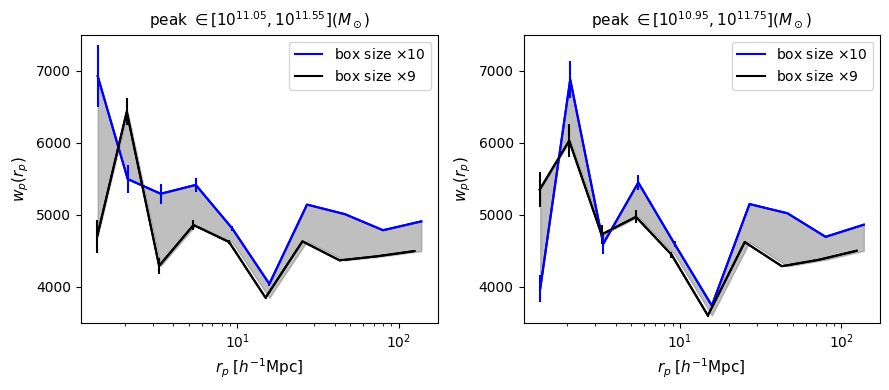

In [157]:
# plot
fig,ax = plt.subplots(1,2, figsize=(9, 4))

ax[0].plot(mean_rp_10_range1, proj_tpcf_10_range1, color='Blue', label=r'box size $\times$10')
ax[0].plot(mean_rp_9_range1, proj_tpcf_9_range1, color='Black', label=r'box size $\times$9')
ax[0].errorbar(mean_rp_10_range1, proj_tpcf_10_range1, yerr=error_proj_tpcf_10_range1, color='Blue')
ax[0].errorbar(mean_rp_9_range1, proj_tpcf_9_range1, yerr=error_proj_tpcf_9_range1, color='Black')
ax[0].fill_between(mean_rp_10_range1, proj_tpcf_10_range1, proj_tpcf_9_range1, color='Grey', alpha=0.5 )
ax[0].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$", fontsize=11)
ax[0].set_ylabel(r"$w_{p} (r_{p})$", fontsize=11)
ax[0].set_title(r'peak $\in [10^{11.05}, 10^{11.55}](M_\odot)$', fontsize=11)
ax[0].set_xscale('log')
#ax[0].set_yscale('log')
ax[0].set_ylim(3500,7500)
ax[0].set_yticks(np.arange(4000,8000,1000))
ax[0].legend()

ax[1].plot(mean_rp_10_range2, proj_tpcf_10_range2, color='Blue', label=r'box size $\times$10')
ax[1].plot(mean_rp_9_range2, proj_tpcf_9_range2, color='Black', label=r'box size $\times$9')
ax[1].errorbar(mean_rp_10_range2, proj_tpcf_10_range2, yerr=error_proj_tpcf_10_range2, color='Blue')
ax[1].errorbar(mean_rp_9_range2, proj_tpcf_9_range2, yerr=error_proj_tpcf_9_range2, color='Black')
ax[1].fill_between(mean_rp_10_range2, proj_tpcf_10_range2, proj_tpcf_9_range2, color='Grey', alpha=0.5 )
ax[1].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$", fontsize=11)
ax[1].set_ylabel(r"$w_{p} (r_{p})$", fontsize=11)
ax[1].set_title(r'peak $\in [10^{10.95}, 10^{11.75}](M_\odot)$', fontsize=11)
ax[1].set_xscale('log')
#ax[1].set_yscale('log')
ax[1].set_ylim(3500,7500)
ax[1].set_yticks(np.arange(4000,8000,1000))
ax[1].legend()

plt.tight_layout();

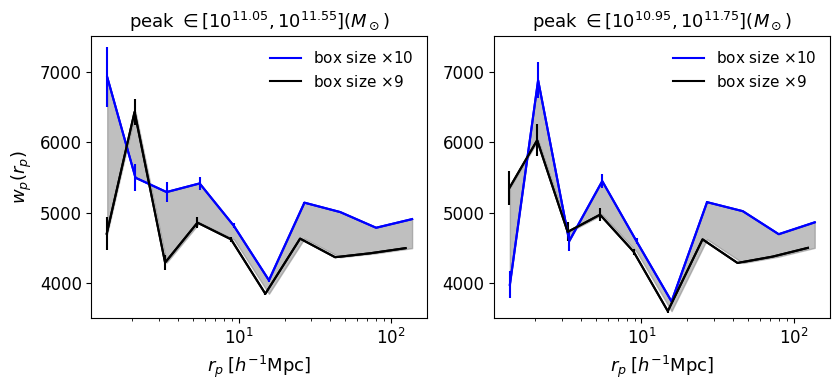

In [20]:
# plot
fig,ax = plt.subplots(1,2, figsize=(8.5, 4))

ax[0].plot(mean_rp_10_range1, proj_tpcf_10_range1, color='Blue', label=r'box size $\times10$')
ax[0].plot(mean_rp_9_range1, proj_tpcf_9_range1, color='Black', label=r'box size $\times9$')
ax[0].errorbar(mean_rp_10_range1, proj_tpcf_10_range1, yerr=error_proj_tpcf_10_range1, color='Blue')
ax[0].errorbar(mean_rp_9_range1, proj_tpcf_9_range1, yerr=error_proj_tpcf_9_range1, color='Black')
ax[0].fill_between(mean_rp_10_range1, proj_tpcf_10_range1, proj_tpcf_9_range1, color='Grey', alpha=0.5 )
ax[0].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$", fontsize=13)
ax[0].set_ylabel(r"$w_{p} (r_{p})$", fontsize=13)
ax[0].set_title(r'peak $\in [10^{11.05}, 10^{11.55}](M_\odot)$', fontsize=13)
ax[0].set_xscale('log')
#ax[0].set_yscale('log')
ax[0].set_ylim(3500,7500)
ax[0].set_yticks(np.arange(4000,8000,1000))
ax[0].legend(fontsize=11, frameon=False)

ax[1].plot(mean_rp_10_range2, proj_tpcf_10_range2, color='Blue', label=r'box size $\times10$')
ax[1].plot(mean_rp_9_range2, proj_tpcf_9_range2, color='Black', label=r'box size $\times9$')
ax[1].errorbar(mean_rp_10_range2, proj_tpcf_10_range2, yerr=error_proj_tpcf_10_range2, color='Blue')
ax[1].errorbar(mean_rp_9_range2, proj_tpcf_9_range2, yerr=error_proj_tpcf_9_range2, color='Black')
ax[1].fill_between(mean_rp_10_range2, proj_tpcf_10_range2, proj_tpcf_9_range2, color='Grey', alpha=0.5 )
ax[1].set_xlabel(r"$r_{p} \; [h^{-1} \mathrm{Mpc}]$", fontsize=13)
#ax[1].set_ylabel(r"$w_{p} (r_{p})$", fontsize=13)
ax[1].set_title(r'peak $\in [10^{10.95}, 10^{11.75}](M_\odot)$', fontsize=13)
ax[1].set_xscale('log')
#ax[1].set_yscale('log')
ax[1].set_ylim(3500,7500)
ax[1].set_yticks(np.arange(4000,8000,1000))
ax[1].legend(fontsize=11, frameon=False)

for i in range(2):
        ax[i].tick_params(labelsize=12)

plt.tight_layout()
plt.rc('pgf', texsystem='pdflatex')
plt.savefig('repl_tpcf.pgf');

### Mass distribution

- peak range:  $11.05 < \log M_\star/M_\odot < 11.55$

In [101]:
replications = 10

# get galaxies within the mass range peak
mass_small = np.log10([i.masses['stellar'] for i in obj.galaxies])
mass_large_all = np.hstack([mass_small] * replications**3)
print(len(mass_large_all))

mass_range1 = mass_large_all[(mass_large_all<11.05) | (mass_large_all>11.55)]
mass_range2 = mass_large_all[(mass_large_all>11.05) & (mass_large_all<11.55)]

print(N_gal_obs_total)

# Number of galaxies outside the mass range peak according to observation
N_gal_mass_range1 = N_gal_obs_total - len(mass_range2)

# Randomnly select elements to align with observed counts
np.random.seed(0)
remaining_mass = np.random.choice(mass_range1, size=N_gal_mass_range1, replace=False)

# The final galaxy mass
# combine the two outside and within the mass range peak 
mass_large_10_range1 = np.hstack([remaining_mass, mass_range2])

# Simba stellar mass
original_simba = np.log10([i.masses['stellar'] for i in obj.galaxies])

5685000
132693


In [102]:
replications = 9

# get galaxies within the mass range peak
mass_small = np.log10([i.masses['stellar'] for i in obj.galaxies])
mass_large_all = np.hstack([mass_small] * replications**3)
print(len(mass_large_all))

mass_range1 = mass_large_all[(mass_large_all<11.05) | (mass_large_all>11.55)]
mass_range2 = mass_large_all[(mass_large_all>11.05) & (mass_large_all<11.55)]

print(N_gal_obs_total)

# Number of galaxies outside the mass range peak according to observation
N_gal_mass_range1 = N_gal_obs_total - len(mass_range2)


# Randomnly select elements to align with observed counts
np.random.seed(0)
remaining_mass = np.random.choice(mass_range1, size=N_gal_mass_range1, replace=False)

# The final galaxy mass
# combine the two outside and within the mass range peak 
mass_large_9_range1 = np.hstack([remaining_mass, mass_range2])

# Simba stellar mass
original_simba = np.log10([i.masses['stellar'] for i in obj.galaxies])

4144365
132693


- peak range:  $10.95 < \log M_\star/M_\odot < 11.75$

In [103]:
replications = 10

# get galaxies within the mass range peak
mass_small = np.log10([i.masses['stellar'] for i in obj.galaxies])
mass_large_all = np.hstack([mass_small] * replications**3)
print(len(mass_large_all))

mass_range1 = mass_large_all[(mass_large_all<10.95) | (mass_large_all>11.75)]
mass_range2 = mass_large_all[(mass_large_all>10.95) & (mass_large_all<11.75)]

print(N_gal_obs_total)

# Number of galaxies outside the mass range peak according to observation
N_gal_mass_range1 = N_gal_obs_total - len(mass_range2)

# Randomnly select elements to align with observed counts
np.random.seed(0)
remaining_mass = np.random.choice(mass_range1, size=N_gal_mass_range1, replace=False)

# The final galaxy mass
# combine the two outside and within the mass range peak 
mass_large_10_range2 = np.hstack([remaining_mass, mass_range2])

# Simba stellar mass
original_simba = np.log10([i.masses['stellar'] for i in obj.galaxies])

5685000
132693


In [160]:
replications = 9
replications = 10

# get galaxies within the mass range peak
mass_small = np.log10([i.masses['stellar'] for i in obj.galaxies])
mass_large_all = np.hstack([mass_small] * replications**3)
print(len(mass_large_all))

mass_range1 = mass_large_all[(mass_large_all<10.95) | (mass_large_all>11.75)]
mass_range2 = mass_large_all[(mass_large_all>10.95) & (mass_large_all<11.75)]

print(N_gal_obs_total)

# Number of galaxies outside the mass range peak according to observation
N_gal_mass_range1 = N_gal_obs_total - len(mass_range2)


# Randomnly select elements to align with observed counts
np.random.seed(0)
remaining_mass = np.random.choice(mass_range1, size=N_gal_mass_range1, replace=False)

# The final galaxy mass
# combine the two outside and within the mass range peak 
mass_large_9_range2 = np.hstack([remaining_mass, mass_range2])

# Simba stellar mass
original_simba = np.log10([i.masses['stellar'] for i in obj.galaxies])

4144365
132693


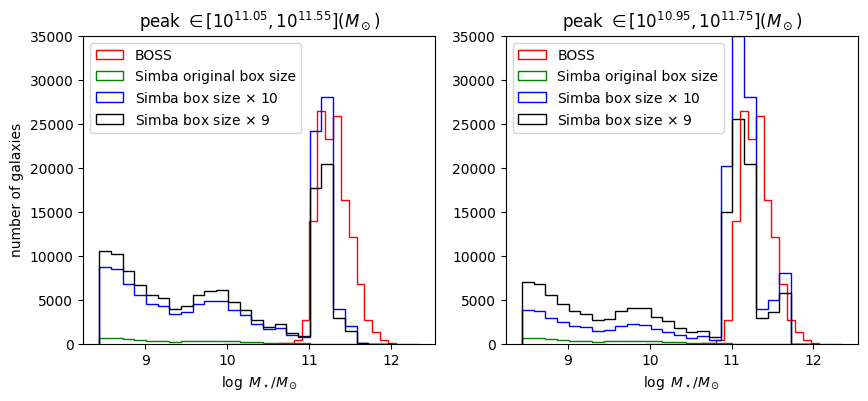

In [141]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

ax[0].hist(original_x, bins=25, weights=original_y, histtype='step', color='Red', label='BOSS')
ax[0].hist(original_simba, bins=25, histtype='step', color='Green', label='Simba original box size')
ax[0].hist(mass_large_10_range1, bins=25, histtype='step', color='Blue', label=r'Simba box size $\times$ 10')
ax[0].hist(mass_large_9_range1, bins=25, histtype='step', color='Black', label=r'Simba box size $\times$ 9')
ax[0].set_title(r'peak $\in [10^{11.05}, 10^{11.55}](M_\odot)$')
ax[0].set_xlabel(r"$\log \;M_\star / M_\odot$")
ax[0].set_ylabel('number of galaxies')
ax[0].set_ylim(0,35000)
ax[0].legend()

ax[1].hist(original_x, bins=25, weights=original_y, histtype='step', color='Red', label='BOSS')
ax[1].hist(original_simba, bins=25, histtype='step', color='Green', label='Simba original box size')
ax[1].hist(mass_large_10_range2, bins=25, histtype='step', color='Blue', label=r'Simba box size $\times$ 10')
ax[1].hist(mass_large_9_range2, bins=25, histtype='step', color='Black', label=r'Simba box size $\times$ 9')
ax[1].set_title(r'peak $\in [10^{10.95}, 10^{11.75}](M_\odot)$')
ax[1].set_xlabel(r"$\log \;M_\star / M_\odot$")
#ax[1].set_ylabel('number of galaxies')
ax[1].set_ylim(0,35000)
ax[1].legend()

plt.tight_layout;

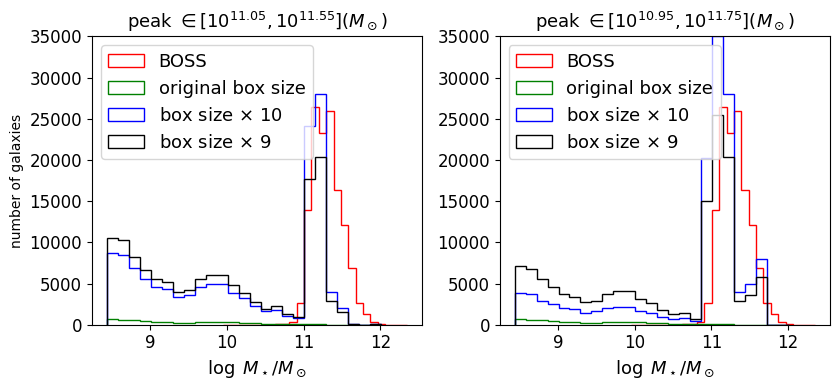

In [148]:
fig, ax = plt.subplots(1,2, figsize=(8.5,4))

ax[0].hist(original_x, bins=25, weights=original_y, histtype='step', color='Red', label='BOSS')
ax[0].hist(original_simba, bins=25, histtype='step', color='Green', label='original box size')
ax[0].hist(mass_large_10_range1, bins=25, histtype='step', color='Blue', label=r'box size $\times$ 10')
ax[0].hist(mass_large_9_range1, bins=25, histtype='step', color='Black', label=r'box size $\times$ 9')
ax[0].set_title(r'peak $\in [10^{11.05}, 10^{11.55}](M_\odot)$', fontsize=13)
ax[0].set_xlabel(r"$\log \;M_\star / M_\odot$", fontsize=13)
ax[0].set_ylabel('number of galaxies')
ax[0].set_ylim(0,35000)
ax[0].legend(fontsize=13)

ax[1].hist(original_x, bins=25, weights=original_y, histtype='step', color='Red', label='BOSS')
ax[1].hist(original_simba, bins=25, histtype='step', color='Green', label='original box size')
ax[1].hist(mass_large_10_range2, bins=25, histtype='step', color='Blue', label=r'box size $\times$ 10')
ax[1].hist(mass_large_9_range2, bins=25, histtype='step', color='Black', label=r'box size $\times$ 9')
ax[1].set_title(r'peak $\in [10^{10.95}, 10^{11.75}](M_\odot)$', fontsize=13)
ax[1].set_xlabel(r"$\log \;M_\star / M_\odot$", fontsize=13)
#ax[1].set_ylabel('number of galaxies')
ax[1].set_ylim(0,35000)
ax[1].legend(fontsize=13)

for i in range(2):
        ax[i].tick_params(labelsize=12)

plt.tight_layout()
plt.rc('pgf', texsystem='pdflatex')
plt.savefig('repl_mass_distr.pgf');

In [161]:
# get positions of all galaxies 
pos_all_small = np.transpose(np.array([i.pos.to(unit) for i in obj.galaxies])) 

# Replicate the points_in_smaller_box for each offset and add the offsets to create the larger box
# The result is a (3, N*replications^3) array representing all points in the larger box
pos_all_large = (pos_all_small[:, :, np.newaxis] + offsets_combined[:, np.newaxis, :]).reshape(3, -1)
print(pos_all_large)

[[ 17.2037356   17.2037356   17.2037356  ... 292.19522446 292.19522446
  292.19522446]
 [ 21.07652058  21.07652058  21.07652058 ... 282.430413   282.430413
  282.430413  ]
 [ 25.21305299  58.76030269  92.30755238 ... 218.96091697 252.50816666
  286.05541636]] dimensionless


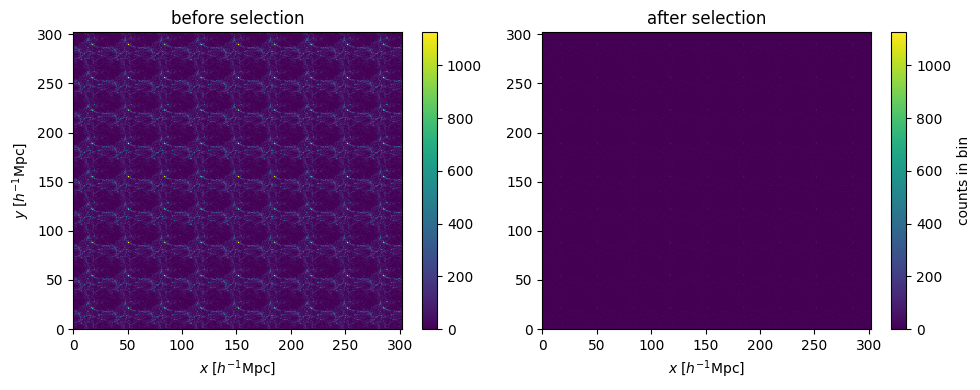

In [162]:
fig, ax = plt.subplots(1,2, figsize=(10,4))

histogram0 = ax[0].hist2d(pos_all_large[0,:], pos_all_large[1,:], bins=300, cmap='viridis')
ax[0].set_title('before selection')
ax[0].set_xlabel(r"$x \; [h^{-1} \mathrm{Mpc}]$")
ax[0].set_ylabel(r"$y \; [h^{-1} \mathrm{Mpc}]$")
ax[0].set_xlim(0, np.max(pos_all_large))
ax[0].set_ylim(0, np.max(pos_all_large))
cbar0 = fig.colorbar(histogram0[3], ax=ax[0])
#cbar0.set_label('counts in bin')

histogram1 = ax[1].hist2d(pos_large[0, :], pos_large[1, :], bins=300, cmap='viridis')
ax[1].set_title('after selection')
ax[1].set_xlabel(r"$x \; [h^{-1} \mathrm{Mpc}]$")
ax[1].set_xlim(0, np.max(pos_large))
ax[1].set_ylim(0, np.max(pos_large))
#ax[1].set_ylabel(r"$y \; [h^{-1} \mathrm{Mpc}]$")
cbar1 = fig.colorbar(histogram1[3], ax=ax[1])
cbar1.set_label('counts in bin')

# Set the same colorbar range for both subplots
vmin = min(histogram0[0].min(), histogram1[0].min())
vmax = max(histogram0[0].max(), histogram1[0].max())
histogram0[3].set_clim(vmin, vmax)
histogram1[3].set_clim(vmin, vmax);

#for i in range(2):
#        ax[i].tick_params(labelsize=13)

plt.tight_layout()
